# E-commerce Funnel Analysis

## Problem Statement
E-commerce platforms often lose users during the purchase journey.  
This analysis aims to identify where users drop off and what factors influence conversion.
## Objective
Analyze user journey data to identify drop-off points and improve conversion rate.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df= pd.read_csv('customer_journey.csv')
df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


In [4]:
df['PageType'].value_counts()

PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: count, dtype: int64

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           12719 non-null  object
 1   UserID              12719 non-null  object
 2   Timestamp           12719 non-null  object
 3   PageType            12719 non-null  object
 4   DeviceType          12719 non-null  object
 5   Country             12719 non-null  object
 6   ReferralSource      12719 non-null  object
 7   TimeOnPage_seconds  12719 non-null  int64 
 8   ItemsInCart         12719 non-null  int64 
 9   Purchased           12719 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 993.8+ KB


,TimeOnPage_seconds,ItemsInCart,Purchased
count,12719.000000,12719.000000,12719.000000
mean,97.427707,1.138533,0.397044
std,48.120729,1.689954,0.489304
min,15.000000,0.000000,0.000000
25%,56.000000,0.000000,0.000000
50%,98.000000,0.000000,0.000000
75%,139.000000,2.000000,1.000000
max,180.000000,5.000000,1.000000


In [6]:
df.isnull().sum()

SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64

In [7]:
df.nunique()

SessionID              5000
UserID                 1872
Timestamp             12713
PageType                  5
DeviceType                3
Country                   7
ReferralSource            4
TimeOnPage_seconds      166
ItemsInCart               6
Purchased                 2
dtype: int64

## Data Cleaning
- Removed duplicates
- Converted timestamps
- Sorted data by session

In [8]:
df.drop_duplicates(inplace=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [9]:
df['session_duration'] = df.groupby('SessionID')['Timestamp'].transform(lambda x: (x.max() - x.min()).seconds)
df = df.sort_values(['UserID', 'Timestamp'])
df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased,session_duration
10423,session_4102,user_1001,2025-02-26 15:46:07,home,Mobile,Canada,Email,30,0,0,122
10424,session_4102,user_1001,2025-02-26 15:48:09,product_page,Mobile,Canada,Email,122,3,0,122
7433,session_2922,user_1001,2025-03-30 08:27:58,home,Desktop,Germany,Google,89,0,1,410
7434,session_2922,user_1001,2025-03-30 08:29:35,product_page,Desktop,Germany,Google,97,3,1,410
7435,session_2922,user_1001,2025-03-30 08:30:29,cart,Desktop,Germany,Google,54,3,1,410


In [10]:
funnel_counts = df.groupby('PageType')['SessionID'].nunique()
funnel_counts = funnel_counts.loc[
    ['home', 'product_page', 'cart', 'checkout', 'confirmation']
]
funnel_counts

PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: SessionID, dtype: int64

Text(0.5, 1.0, 'Funnel Counts')

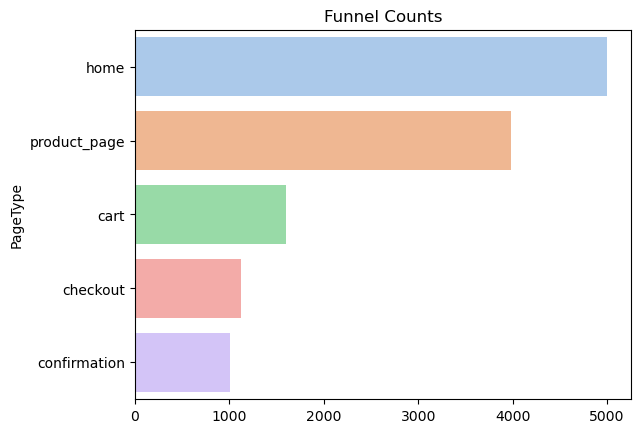

In [45]:
sns.barplot(y= funnel_counts.index, x=funnel_counts.values, palette= 'pastel')
plt.title("Funnel Counts")

In [11]:
conversion_rate = (funnel_counts / funnel_counts.iloc[0]).round(2)
conversion_rate

PageType
home            1.00
product_page    0.80
cart            0.32
checkout        0.22
confirmation    0.20
Name: SessionID, dtype: float64

In [31]:
drop_off_step = conversion_rate.diff()
drop_off_step

PageType
home             NaN
product_page   -0.20
cart           -0.48
checkout       -0.10
confirmation   -0.02
Name: SessionID, dtype: float64

### Insight
Significant drop (~48%) occurs between product page and cart stage.

In [14]:
session_df = df.groupby('SessionID').agg({
    'DeviceType': 'first',
    'Country': 'first',
    'ReferralSource': 'first',
    'TimeOnPage_seconds': 'sum',
    'ItemsInCart': 'max',
    'Purchased': 'max'
}).reset_index()
session_df

,SessionID,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,Desktop,India,Social Media,55,0,0
1,session_1,Tablet,Germany,Email,220,0,0
2,session_10,Tablet,India,Direct,191,0,0
3,session_100,Desktop,USA,Email,101,1,0
4,session_1000,Mobile,France,Email,474,3,1
...,...,...,...,...,...,...,...
4995,session_995,Mobile,USA,Google,239,5,0
4996,session_996,Desktop,France,Social Media,318,0,0
4997,session_997,Desktop,USA,Direct,492,4,1
4998,session_998,Desktop,Australia,Social Media,83,0,0


In [15]:
added_to_cart = session_df[session_df['ItemsInCart'] > 0]
not_added_to_cart = session_df[session_df['ItemsInCart'] == 0]

In [16]:
added_to_cart['TimeOnPage_seconds'].mean(), not_added_to_cart['TimeOnPage_seconds'].mean()

(np.float64(317.63770604395603), np.float64(150.48946360153258))

In [17]:
session_df.groupby('DeviceType')['ItemsInCart'].apply(lambda x: (x > 0).mean())

DeviceType
Desktop    0.570228
Mobile     0.587074
Tablet     0.589898
Name: ItemsInCart, dtype: float64

In [18]:
session_df.groupby(
    (session_df['ItemsInCart'] > 0)
)['TimeOnPage_seconds'].mean()

ItemsInCart
False    150.489464
True     317.637706
Name: TimeOnPage_seconds, dtype: float64

### Insight
Users who spend more time are significantly more likely to convert (~2x difference).
Device type does not significantly impact conversion.

In [19]:
session_df.groupby('ReferralSource')['Purchased'].mean().sort_values(ascending=False)

ReferralSource
Google          0.216406
Email           0.200639
Direct          0.198206
Social Media    0.192277
Name: Purchased, dtype: float64

In [23]:
high_intent_lost = session_df[
    (session_df['ItemsInCart'] > 0) & (session_df['Purchased'] == 0)
]
total_sessions = len(session_df)
len(high_intent_lost), total_sessions

(1902, 5000)

In [24]:
lost_percentage = len(high_intent_lost) / total_sessions * 100
lost_percentage

38.04

### Insight
~38% of users who added items to cart did not complete purchase, indicating major opportunity for conversion optimization.

In [25]:
session_df.groupby('Country')['Purchased'].mean().sort_values(ascending=False)

Country
France       0.226064
USA          0.208215
India        0.206553
UK           0.196211
Canada       0.195804
Australia    0.191801
Germany      0.187767
Name: Purchased, dtype: float64

In [26]:
funnel_df = pd.DataFrame({
    'Stage': funnel_counts.index,
    'Users': funnel_counts.values,
    'ConversionRate': conversion_rate.values
})
funnel_df

,Stage,Users,ConversionRate
0,home,5000,1.00
1,product_page,3987,0.80
2,cart,1599,0.32
3,checkout,1123,0.22
4,confirmation,1010,0.20


In [27]:
session_df.to_excel("session_data.xlsx", index=False)
funnel_df.to_excel("funnel_data.xlsx", index=False)

In [28]:
session_df.head()

,SessionID,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,Desktop,India,Social Media,55,0,0
1,session_1,Tablet,Germany,Email,220,0,0
2,session_10,Tablet,India,Direct,191,0,0
3,session_100,Desktop,USA,Email,101,1,0
4,session_1000,Mobile,France,Email,474,3,1


In [29]:
funnel_df

,Stage,Users,ConversionRate
0,home,5000,1.00
1,product_page,3987,0.80
2,cart,1599,0.32
3,checkout,1123,0.22
4,confirmation,1010,0.20


## Key Findings

- 48% drop at product → cart stage  
- Engagement strongly correlates with conversion  
- 38% high-intent users drop off  
- Traffic sources show similar conversion rates  

## Recommendations

- Improve product page UX and clarity  
- Simplify checkout process  
- Retarget high-intent users  
- Increase engagement via personalization  